In [4]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load PLINK PCA file (no header)
pca = pd.read_csv('../data/final_dataset/afterqc_pca.eigenvec', delim_whitespace=True, header=None)

# Add column names: FID, IID, PC1, PC2, ..., PC10
num_pcs = pca.shape[1] - 2
pc_cols = [f'PC{i+1}' for i in range(num_pcs)]
pca.columns = ['FID', 'IID'] + pc_cols

In [18]:
eigenvals = pd.read_csv('../data/final_dataset/afterqc_pca.eigenval', header=None).squeeze()
variance_explained = 100 * eigenvals / eigenvals.sum()

In [8]:
# Load metadata
metadata = pd.read_csv('../data/final_dataset/metadata.txt', sep="\t")

# Check first few lines to confirm columns
print(metadata.head())

    user build            chip chip_version inferred_sex  \
0  10645    37             NaN          NaN       Female   
1  10542    37  HTS iSelect HD           v4       Female   
2  10653    37             NaN          NaN       Female   
3  10106    37             NaN          NaN       Female   
4  10559    37   Illumina GSAs           v5         Male   

                     source  
0               AncestryDNA  
1                   23andMe  
2  AncestryDNA, AncestryDNA  
3               AncestryDNA  
4                   23andMe  


In [11]:
# Rename metadata column 'user' to 'IID' to match PCA column
metadata = metadata.rename(columns={'user': 'IID'})

# also, IID in metadata and the IID in PCA-data have different formats, which makes pandas unhappy
# solution, convert to string
# Convert IID columns to strings for both dataframes
pca['IID'] = pca['IID'].astype(str)
metadata['IID'] = metadata['IID'].astype(str)

# merge PCA and metadata on IID
merged = pd.merge(pca, metadata[['IID', 'chip']], on='IID', how='left')

   FID IID       PC1       PC2       PC3       PC4       PC5       PC6  \
0    8   8 -0.008445 -0.003016 -0.026276 -0.007117 -0.050784  0.008315   
1   11  11  0.003432  0.003137 -0.098145  0.000687 -0.142810  0.000109   
2   16  16 -0.013018 -0.008513  0.009539 -0.010622  0.010993  0.002677   
3   33  33  0.053377  0.154502 -0.198326 -0.029830  0.153092 -0.006717   
4   40  40  0.011128  0.010066  0.017190  0.020743 -0.023114  0.000505   

        PC7       PC8       PC9      PC10              chip  
0 -0.009766  0.014929 -0.023920  0.007350  OmniExpress plus  
1 -0.031529  0.015546 -0.033441  0.038281  OmniExpress plus  
2 -0.016318  0.014601 -0.025513  0.011584    HTS iSelect HD  
3  0.006727  0.000032 -0.003008 -0.005269  OmniExpress plus  
4  0.012647  0.002277  0.038035 -0.072575  OmniExpress plus  


In [19]:
# how much percentage of variance is explained - prep
pc1_var = variance_explained[0]
pc2_var = variance_explained[1]
pc3_var = variance_explained[2]

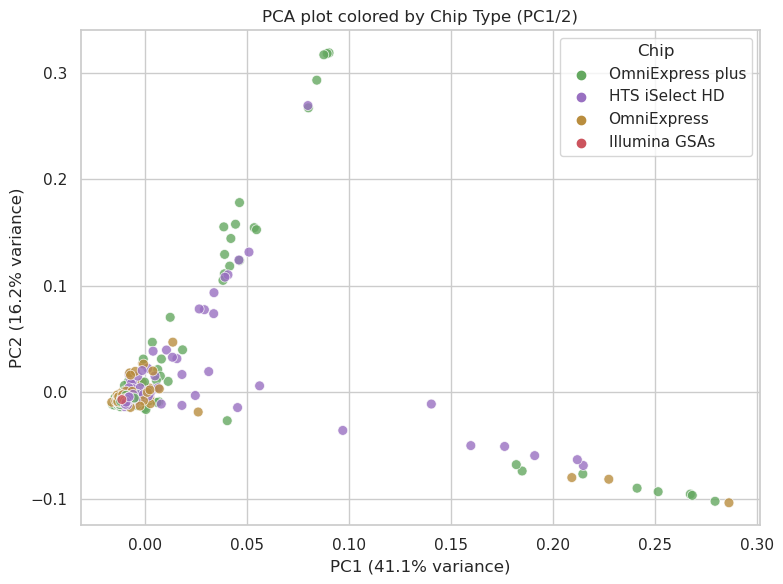

In [20]:
# the final plot
# Set plot style
sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

# yes, i am playing with the colours, don't judge
custom_palette = ["#64a860",
                  "#9970c1",
                  "#b98d3e",
                  "#cc545e"]

# Scatterplot of PC1 vs PC2 colored by chip
sns.scatterplot(
    data=merged,
    x='PC1',
    y='PC2',
    hue='chip',
    palette=custom_palette,
    s=50,
    alpha=0.8
)

plt.title('PCA plot colored by Chip Type (PC1/2)')
plt.xlabel(f'PC1 ({pc1_var:.1f}% variance)')
plt.ylabel(f'PC2 ({pc2_var:.1f}% variance)')
plt.legend(title='Chip')
plt.tight_layout()
plt.show()

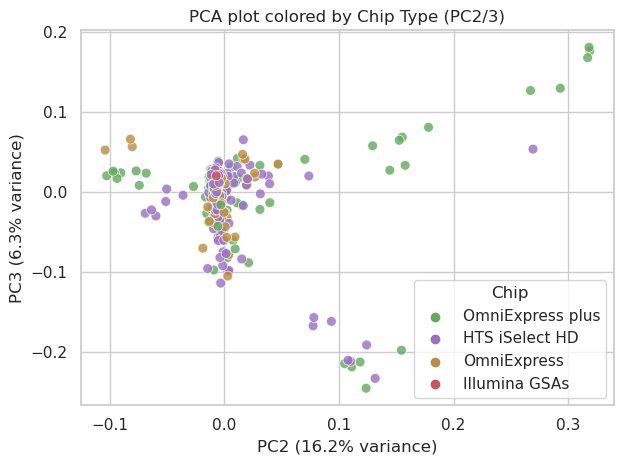

In [21]:
# and because it is fun, also PC2 and PC3
# Scatterplot of PC1 vs PC2 colored by chip
sns.scatterplot(
    data=merged,
    x='PC2',
    y='PC3',
    hue='chip',
    palette=custom_palette,
    s=50,
    alpha=0.8
)

plt.title('PCA plot colored by Chip Type (PC2/3)')
plt.xlabel(f'PC2 ({pc2_var:.1f}% variance)')
plt.ylabel(f'PC3 ({pc3_var:.1f}% variance)')
plt.legend(title='Chip')
plt.tight_layout()
plt.show()